# Classificazione di immagini con MNIST e PyTorch

## Il dataset MNIST

**MNIST** (Modified National Institute of Standards and Technology) è il "Hello World" del deep learning applicato alle immagini.  
Contiene **70.000 immagini** in scala di grigi di cifre scritte a mano (0–9):

| Split | Campioni |
|---|---|
| Training set | 60.000 |
| Test set | 10.000 |

Ogni immagine è un tensore di forma **28×28 pixel**, con valori interi da 0 (nero) a 255 (bianco).

---

## Obiettivo

Costruire un modello che, data un'immagine 28×28 di una cifra, **predica correttamente il digit (0–9)**.

Confronteremo due approcci:
1. **MLP** (Multi-Layer Perceptron) — rete fully connected, come in Iris ma più profonda
2. **CNN** (Convolutional Neural Network) — architettura pensata appositamente per le immagini

---

## Perché le CNN sono migliori degli MLP sulle immagini?

Un MLP "appiattisce" l'immagine in un vettore di 784 valori e perde completamente la **struttura spaziale** (il fatto che i pixel vicini sono correlati).

Una CNN invece applica **filtri convoluzionali** che scorrono sull'immagine e imparano a riconoscere pattern locali (bordi, curve, angoli) — esattamente come fa il sistema visivo umano.


## 1. Import delle librerie

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## 2. Device

Su Mac M4 utilizziamo **MPS** per sfruttare la GPU Apple Silicon.


In [33]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print("Using device:", device)

Using device: mps


## 3. Caricamento del dataset

### Transforms

Prima di passare le immagini alla rete, applichiamo due trasformazioni:

- **`ToTensor()`** — converte l'immagine PIL (valori 0–255) in un tensore float32 con valori in [0, 1]
- **`Normalize((0.1307,), (0.3081,))`** — standardizza con la **media** (0.1307) e la **deviazione standard** (0.3081) calcolate sull'intero training set di MNIST

Questo porta i valori dei pixel in un range centrato sullo zero, che aiuta la convergenza della rete.

### DataLoader

Il `DataLoader` gestisce il **batching** automatico: invece di passare tutte le 60.000 immagini insieme (impossibile in memoria), le suddivide in **mini-batch** da 64 immagini.

- `shuffle=True` sul training set → mescola i dati ad ogni epoch per evitare che l'ordine influenzi l'apprendimento
- `shuffle=False` sul test set → l'ordine non conta per la valutazione


In [34]:
# Trasformazioni: converti in tensore e normalizza
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download automatico del dataset (prima volta ~11MB)
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader: gestisce il batching
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples:     {len(test_dataset):,}")
print(f"Batch size:       64")
print(f"Training batches: {len(train_loader)}")
print(f"Shape di un batch: {next(iter(train_loader))[0].shape}  → (batch, canali, H, W)")

Training samples: 60,000
Test samples:     10,000
Batch size:       64
Training batches: 938
Shape di un batch: torch.Size([64, 1, 28, 28])  → (batch, canali, H, W)


## 4. Esplorazione visiva del dataset

Visualizziamo alcuni campioni per capire con cosa stiamo lavorando.


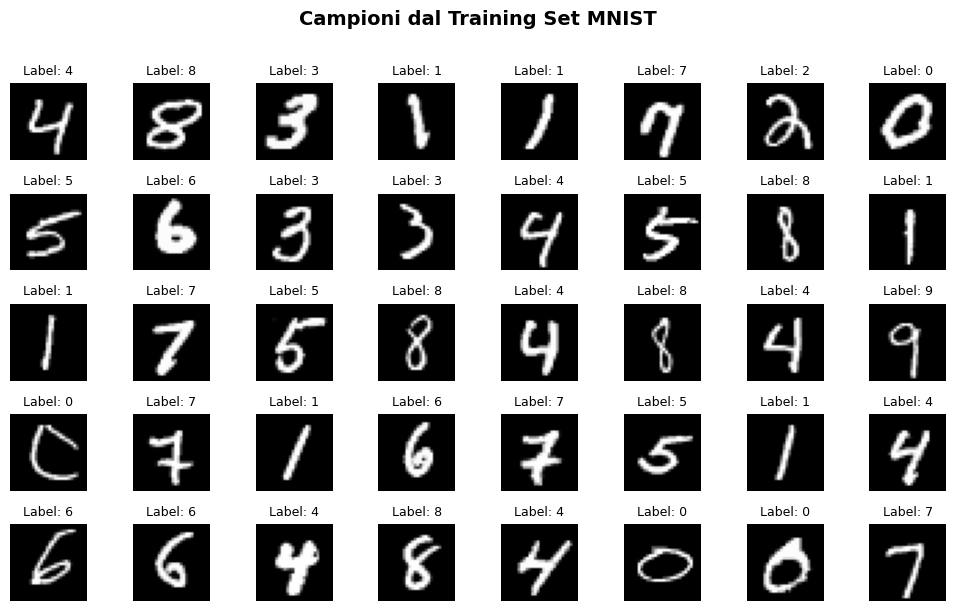

In [35]:
# Prendi un batch dal training loader
images, labels = next(iter(train_loader))

# Mostra 40 immagini in una griglia 5x8
fig, axes = plt.subplots(5, 8, figsize=(10, 6))
fig.suptitle("Campioni dal Training Set MNIST", fontsize=14, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()     # rimuovi la dimensione del canale
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Distribuzione delle classi

Verifichiamo che il dataset sia bilanciato (ogni cifra ha circa lo stesso numero di campioni).


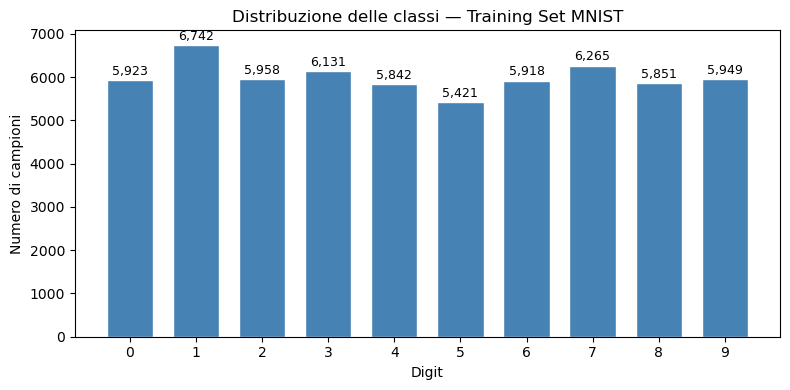

In [36]:
# Conta campioni per classe nel training set
all_labels = train_dataset.targets.numpy()
classi, conteggi = np.unique(all_labels, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(classi, conteggi, color='steelblue', edgecolor='white', width=0.7)
ax.set_xlabel("Digit")
ax.set_ylabel("Numero di campioni")
ax.set_title("Distribuzione delle classi — Training Set MNIST")
ax.set_xticks(classi)

for bar, count in zip(bars, conteggi):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Un'immagine nel dettaglio

Ogni immagine è una **matrice 28×28** di valori float. Visualizziamola insieme alla sua rappresentazione numerica.


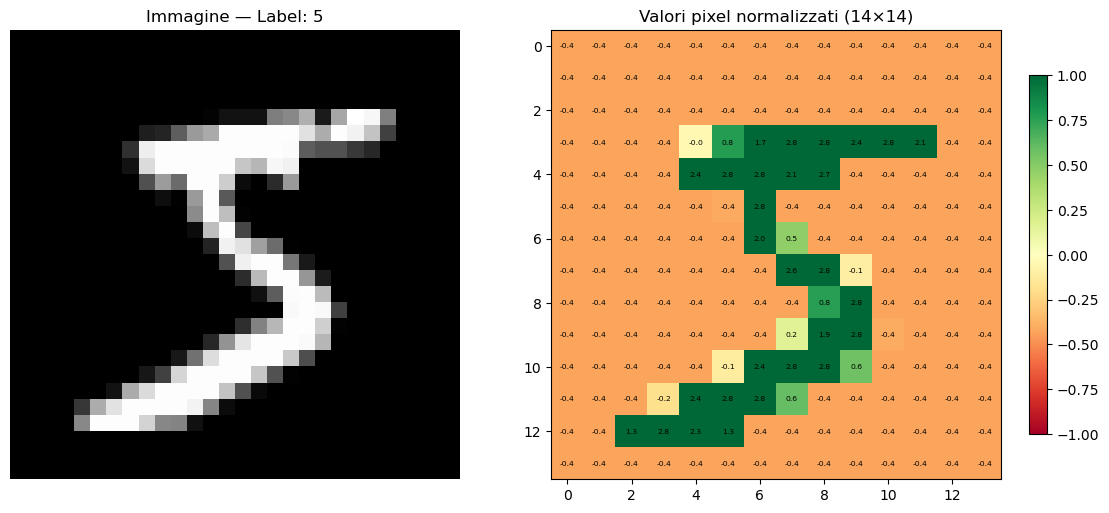

Shape tensore: torch.Size([1, 28, 28]) → (canali, H, W)
Min: -0.424 | Max: 2.821


In [37]:
# Prendi un singolo campione
sample_img, sample_label = train_dataset[0]
pixel_matrix = sample_img.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Immagine
axes[0].imshow(pixel_matrix, cmap='gray')
axes[0].set_title(f"Immagine — Label: {sample_label}", fontsize=12)
axes[0].axis('off')

# Heatmap dei valori numerici (mostra solo 14x14 per leggibilità)
half = pixel_matrix[::2, ::2]   # downsampling 2x
im = axes[1].imshow(half, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_title("Valori pixel normalizzati (14×14)", fontsize=12)
for i in range(half.shape[0]):
    for j in range(half.shape[1]):
        axes[1].text(j, i, f'{half[i,j]:.1f}', ha='center', va='center',
                     fontsize=5.5, color='black')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()
print(f"Shape tensore: {sample_img.shape} → (canali, H, W)")
print(f"Min: {pixel_matrix.min():.3f} | Max: {pixel_matrix.max():.3f}")

## 5. Modello 1 — MLP (Multi-Layer Perceptron)

### Architettura

```
Input: 28×28 = 784 pixel (appiattiti)
    ↓
Linear(784 → 256) + ReLU + Dropout(0.2)
    ↓
Linear(256 → 128) + ReLU + Dropout(0.2)
    ↓
Linear(128 → 10)   ← 10 classi (0–9)
```

### Dropout

Il **Dropout** è una tecnica di regolarizzazione: durante il training, "spegne" casualmente una frazione dei neuroni ad ogni forward pass.  
Questo impedisce alla rete di fare overfitting (memorizzare il training set invece di generalizzare).

> Con `p=0.2`, il 20% dei neuroni viene azzerato ad ogni step durante il training.  
> Durante la valutazione (`model.eval()`), il dropout è automaticamente disabilitato.

### `nn.Flatten`

`nn.Flatten()` trasforma il tensore di forma `(batch, 1, 28, 28)` in `(batch, 784)`.  
L'MLP non "vede" la struttura 2D dell'immagine — lavora su un vettore piatto.


In [38]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                    # (batch,1,28,28) → (batch,784)
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 10)              # logits per 10 classi
        )

    def forward(self, x):
        return self.net(x)

mlp = MLP().to(device)
n_params_mlp = sum(p.numel() for p in mlp.parameters())
print(mlp)
print(f"\nParametri totali MLP: {n_params_mlp:,}")

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parametri totali MLP: 235,146


## 6. Modello 2 — CNN (Convolutional Neural Network)

### Perché le convoluzioni?

Una **convoluzione** applica un piccolo filtro (es. 3×3) che scorre sull'immagine calcolando il prodotto scalare locale.  
Ogni filtro impara a riconoscere un pattern specifico: bordi verticali, orizzontali, curve, angoli, ecc.

I vantaggi rispetto all'MLP:
- **Parameter sharing**: lo stesso filtro viene applicato ovunque → molto meno parametri
- **Località**: i pattern visivi sono locali (un bordo è definito da pochi pixel vicini)
- **Equivarianza alla traslazione**: il filtro riconosce lo stesso pattern ovunque nell'immagine

### Max Pooling

Dopo ogni strato convoluzionale, il **MaxPooling** (2×2) dimezza le dimensioni spaziali prendendo il valore massimo in ogni regione 2×2.  
Effetto: riduce la risoluzione, aumenta il campo recettivo, rende la rete più robusta a piccole traslazioni.

### Architettura

```
Input: (batch, 1, 28, 28)
    ↓
Conv2d(1→32, 3×3) + ReLU → (batch, 32, 26, 26)
    ↓
MaxPool2d(2×2)            → (batch, 32, 13, 13)
    ↓
Conv2d(32→64, 3×3) + ReLU → (batch, 64, 11, 11)
    ↓
MaxPool2d(2×2)            → (batch, 64, 5, 5)
    ↓
Flatten                   → (batch, 1600)
    ↓
Linear(1600→128) + ReLU + Dropout(0.3)
    ↓
Linear(128→10)            ← 10 classi
```


In [39]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Blocco convoluzionale 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # Blocco convoluzionale 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        # Classificatore fully connected
        self.fc1     = nn.Linear(64 * 5 * 5, 128)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2     = nn.Linear(128, 10)

    def forward(self, x):
        # Conv1 → ReLU → Pool
        x = self.pool(F.relu(self.conv1(x)))   # → (batch, 32, 13, 13)

        # Conv2 → ReLU → Pool
        x = self.pool(F.relu(self.conv2(x)))   # → (batch, 64, 5, 5)

        # Flatten
        x = x.view(x.size(0), -1)              # → (batch, 1600)

        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                         # logits
        return x

cnn = CNN().to(device)
n_params_cnn = sum(p.numel() for p in cnn.parameters())
print(cnn)
print(f"\nParametri totali CNN: {n_params_cnn:,}")
print(f"Parametri totali MLP: {n_params_mlp:,}")
print(f"La CNN ha {n_params_mlp/n_params_cnn:.1f}x meno parametri dell'MLP")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Parametri totali CNN: 225,034
Parametri totali MLP: 235,146
La CNN ha 1.0x meno parametri dell'MLP


## 7. Training

### Funzione di training

Creiamo una funzione generica `train_model` riutilizzabile per entrambi i modelli.

**Differenza rispetto a Iris:**
- Su Iris passavamo tutto il dataset in un solo forward pass
- Su MNIST usiamo i **mini-batch**: ad ogni epoch iteriamo su tutti i batch del DataLoader

Questo è il training standard per dataset grandi — un'epoch completa = tutti i 60.000 campioni visti una volta.


In [40]:
def train_model(model, train_loader, optimizer, criterion, epochs=10, model_name="Model"):
    model.train()
    loss_history = []
    acc_history  = []

    for epoch in range(epochs):
        running_loss    = 0.0
        correct = total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds    = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        epoch_loss = running_loss / len(train_loader)
        epoch_acc  = correct / total
        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)

        print(f"[{model_name}] Epoch {epoch+1:>2}/{epochs} — "
              f"Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    return loss_history, acc_history

### Training MLP

In [41]:
criterion    = nn.CrossEntropyLoss()
optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=1e-3)

loss_mlp, acc_mlp = train_model(mlp, train_loader, optimizer_mlp, criterion,
                                 epochs=10, model_name="MLP")

[MLP] Epoch  1/10 — Loss: 0.2736 | Acc: 0.9180
[MLP] Epoch  2/10 — Loss: 0.1306 | Acc: 0.9594
[MLP] Epoch  3/10 — Loss: 0.1000 | Acc: 0.9693
[MLP] Epoch  4/10 — Loss: 0.0827 | Acc: 0.9739
[MLP] Epoch  5/10 — Loss: 0.0729 | Acc: 0.9771
[MLP] Epoch  6/10 — Loss: 0.0639 | Acc: 0.9793
[MLP] Epoch  7/10 — Loss: 0.0584 | Acc: 0.9810
[MLP] Epoch  8/10 — Loss: 0.0585 | Acc: 0.9809
[MLP] Epoch  9/10 — Loss: 0.0514 | Acc: 0.9838
[MLP] Epoch 10/10 — Loss: 0.0461 | Acc: 0.9850


### Training CNN

In [42]:
optimizer_cnn = torch.optim.Adam(cnn.parameters(), lr=1e-3)

loss_cnn, acc_cnn = train_model(cnn, train_loader, optimizer_cnn, criterion,
                                 epochs=10, model_name="CNN")

[CNN] Epoch  1/10 — Loss: 0.1711 | Acc: 0.9483
[CNN] Epoch  2/10 — Loss: 0.0605 | Acc: 0.9813
[CNN] Epoch  3/10 — Loss: 0.0436 | Acc: 0.9863
[CNN] Epoch  4/10 — Loss: 0.0340 | Acc: 0.9892
[CNN] Epoch  5/10 — Loss: 0.0292 | Acc: 0.9906
[CNN] Epoch  6/10 — Loss: 0.0242 | Acc: 0.9920
[CNN] Epoch  7/10 — Loss: 0.0207 | Acc: 0.9933
[CNN] Epoch  8/10 — Loss: 0.0175 | Acc: 0.9941
[CNN] Epoch  9/10 — Loss: 0.0160 | Acc: 0.9947
[CNN] Epoch 10/10 — Loss: 0.0136 | Acc: 0.9952


### Curve di training

Confrontiamo le curve di loss e accuracy dei due modelli durante il training.


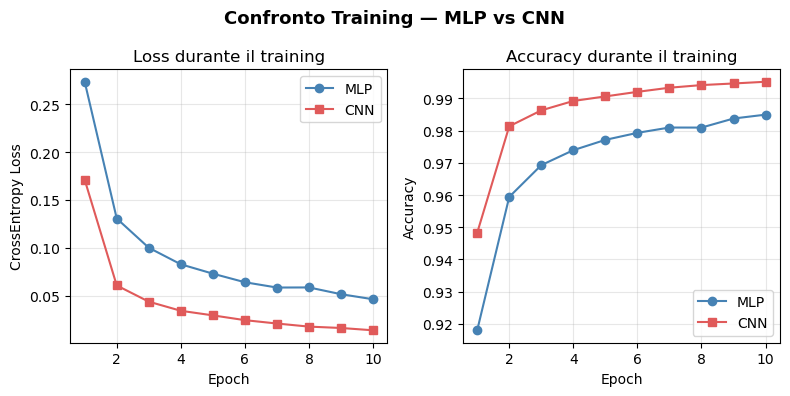

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

epochs_range = range(1, 11)

# Loss
axes[0].plot(epochs_range, loss_mlp, 'o-', label='MLP',  color='steelblue')
axes[0].plot(epochs_range, loss_cnn, 's-', label='CNN',  color='#E05A5A')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].set_title("Loss durante il training")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, acc_mlp, 'o-', label='MLP', color='steelblue')
axes[1].plot(epochs_range, acc_cnn, 's-', label='CNN', color='#E05A5A')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy durante il training")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Confronto Training — MLP vs CNN", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Valutazione sul Test Set

### Funzione di valutazione


In [44]:
def evaluate_model(model, test_loader, model_name="Model"):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds   = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = (all_preds == all_labels).mean()
    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds,
                                 target_names=[str(i) for i in range(10)]))
    return all_preds, all_labels, acc

preds_mlp, labels_test, acc_mlp_test = evaluate_model(mlp, test_loader, "MLP")
preds_cnn, _,           acc_cnn_test = evaluate_model(cnn, test_loader, "CNN")


  MLP — Test Accuracy: 0.9803 (98.03%)
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.96      0.98      0.97       892
           6       0.99      0.97      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.96      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


  CNN — Test Accuracy: 0.9922 (99.22%)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      113

### Confusion Matrix

La confusion matrix su 10 classi ci dice esattamente quali digit vengono confusi tra loro.  
Gli errori più comuni di solito riguardano coppie come **4/9**, **3/8**, **5/6**.


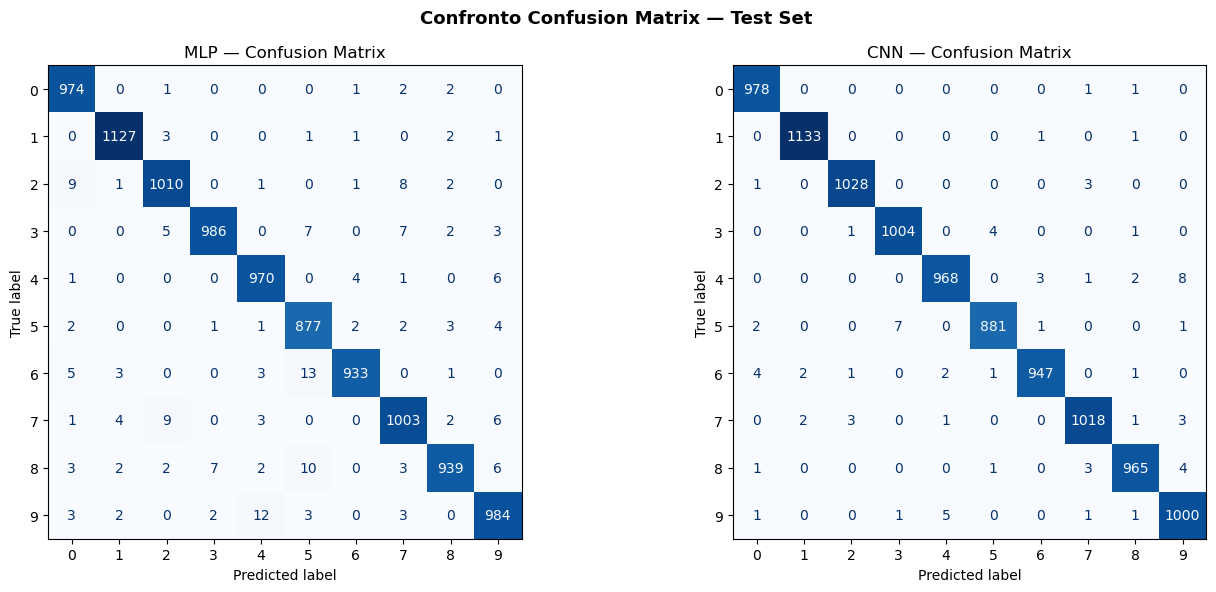

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, title in zip(axes,
                              [preds_mlp, preds_cnn],
                              ["MLP", "CNN"]):
    cm   = confusion_matrix(labels_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=list(range(10)))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{title} — Confusion Matrix", fontsize=12)

plt.suptitle("Confronto Confusion Matrix — Test Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Analisi degli errori

Visualizziamo le immagini che la CNN ha classificato **erroneamente**.  
Spesso si tratta di campioni ambigui anche per un occhio umano!


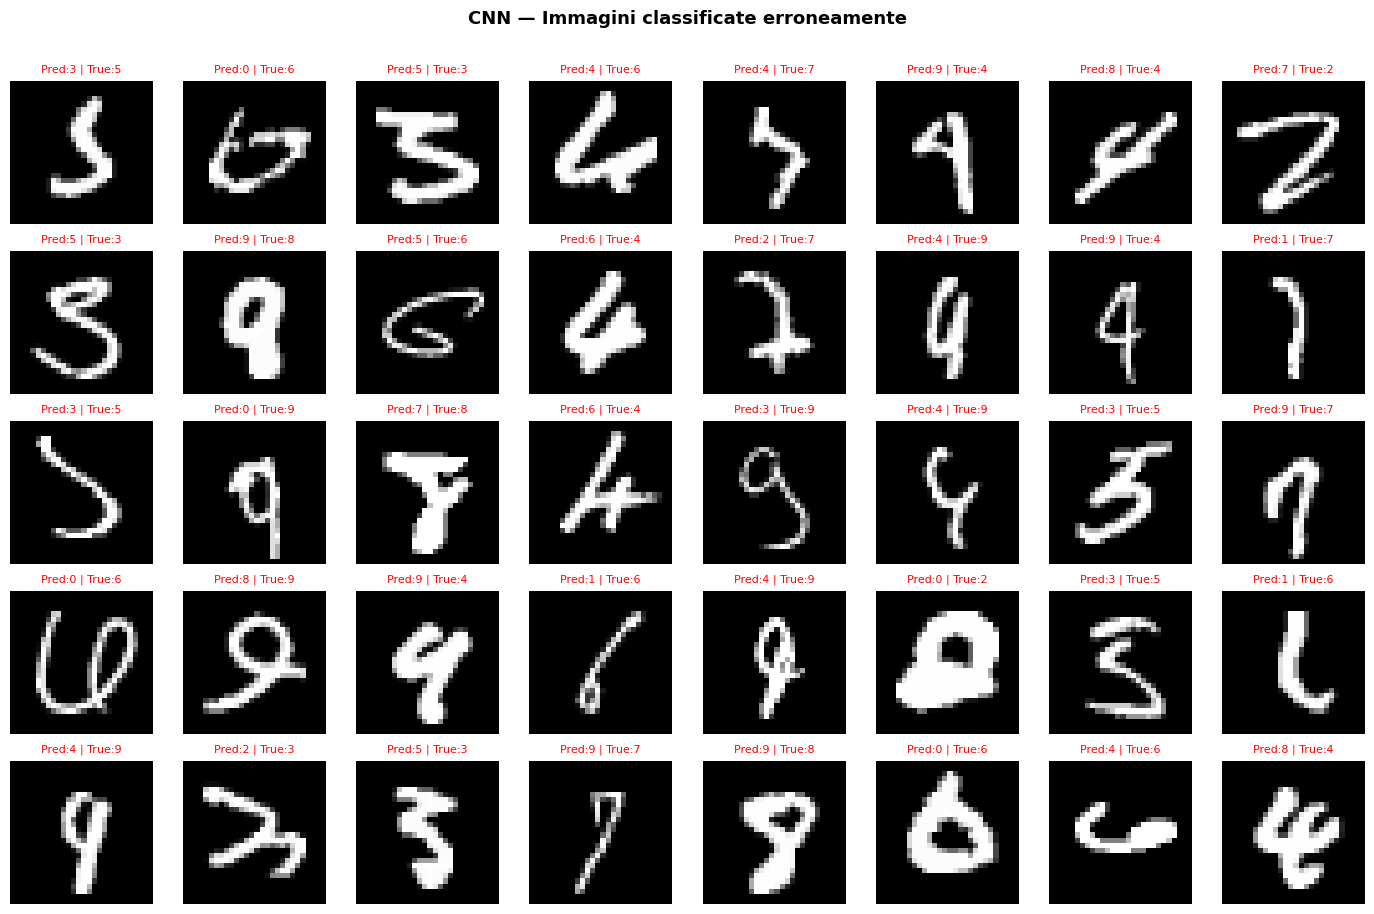

Errori totali CNN sul test set: 78/10000


In [46]:
# Raccogli immagini sbagliate dalla CNN
cnn.eval()
wrong_images = []
wrong_preds  = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = cnn(images.to(device))
        preds   = torch.argmax(outputs, dim=1).cpu()
        mask    = preds != labels
        if mask.any():
            wrong_images.append(images[mask])
            wrong_preds.append(preds[mask])
            wrong_labels.append(labels[mask])
        if sum(len(w) for w in wrong_images) >= 40:
            break

wrong_images = torch.cat(wrong_images)[:40]
wrong_preds  = torch.cat(wrong_preds)[:40]
wrong_labels = torch.cat(wrong_labels)[:40]

# Visualizza
fig, axes = plt.subplots(5, 8, figsize=(14, 9))
fig.suptitle("CNN — Immagini classificate erroneamente", fontsize=13,
             fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    img = wrong_images[i].squeeze().numpy()
    # de-normalizza per visualizzare correttamente
    img = img * 0.3081 + 0.1307
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred:{wrong_preds[i]} | True:{wrong_labels[i]}",
                 fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"Errori totali CNN sul test set: {int((1 - acc_cnn_test) * 10000)}/10000")

## 10. Visualizzazione dei filtri convoluzionali

Cosa ha imparato la CNN? Visualizziamo i **32 filtri del primo strato convoluzionale**.

Ogni filtro è una matrice 3×3 di pesi — i valori chiari e scuri indicano cosa "attiva" quel filtro.  
Nei filtri del primo strato si riconoscono spesso: **rilevatori di bordi**, **gradienti direzionali**, **pattern di contrasto**.


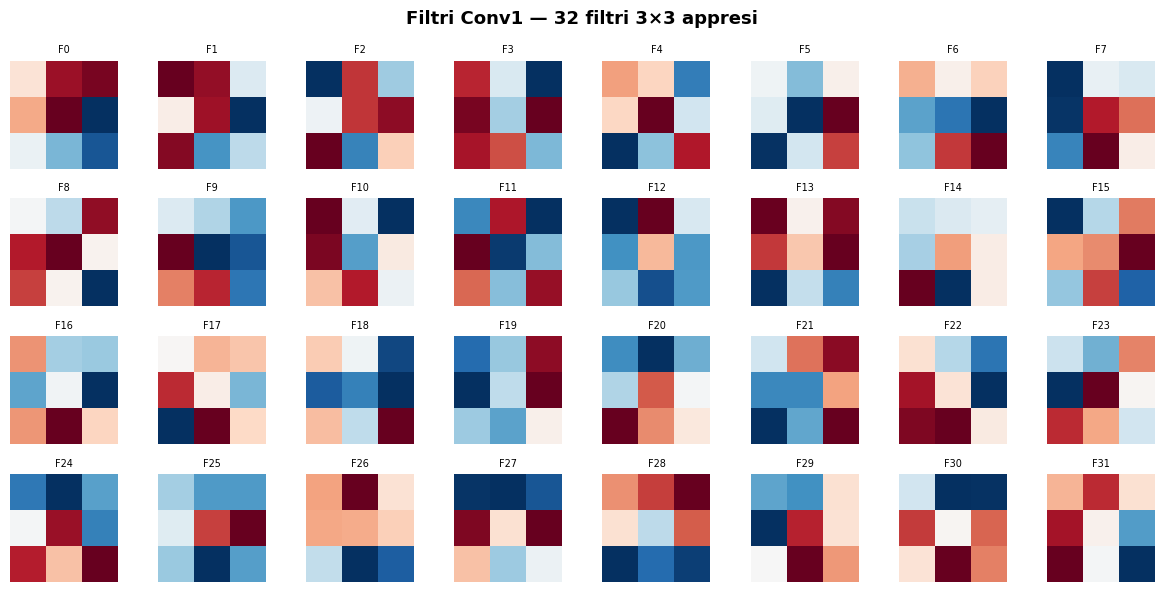

In [47]:
# Estrai i pesi del primo strato conv
filters = cnn.conv1.weight.data.cpu().numpy()   # shape: (32, 1, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle("Filtri Conv1 — 32 filtri 3×3 appresi", fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    f = filters[i, 0]   # shape (3,3)
    ax.imshow(f, cmap='RdBu_r', vmin=f.min(), vmax=f.max())
    ax.axis('off')
    ax.set_title(f"F{i}", fontsize=7)

plt.tight_layout()
plt.show()

### Feature maps

Le **feature maps** sono le attivazioni prodotte dai filtri su un'immagine di input.  
Mostrano cosa "vede" la rete in ciascun canale dopo il primo strato convoluzionale.


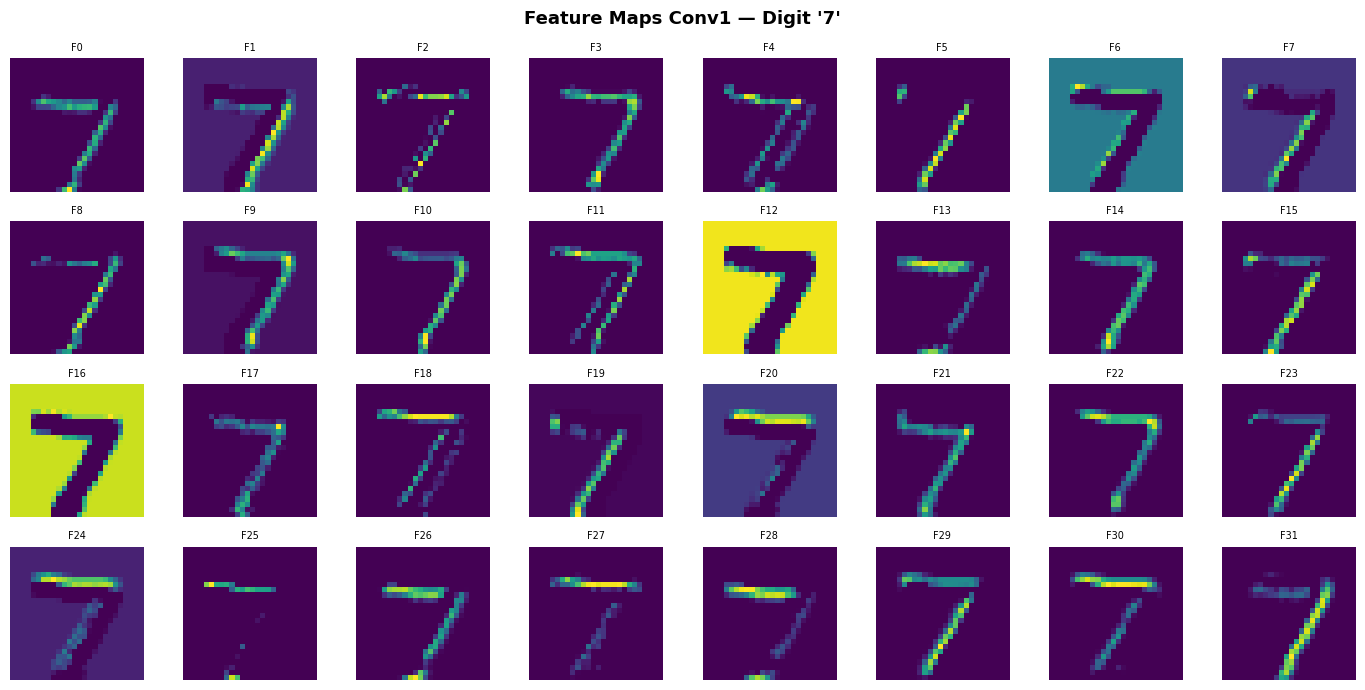

In [48]:
# Prendi un singolo campione
sample_img, sample_label = test_dataset[0]
inp = sample_img.unsqueeze(0).to(device)   # aggiungi dimensione batch → (1,1,28,28)

# Estrai le attivazioni dopo conv1 + ReLU (prima del pooling)
cnn.eval()
with torch.no_grad():
    feature_maps = F.relu(cnn.conv1(inp))   # → (1, 32, 26, 26)

feature_maps = feature_maps.squeeze(0).cpu().numpy()   # → (32, 26, 26)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle(f"Feature Maps Conv1 — Digit '{sample_label}'", fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap='viridis')
    ax.axis('off')
    ax.set_title(f"F{i}", fontsize=7)

plt.tight_layout()
plt.show()

## 11. Confronto finale MLP vs CNN


Modello      Accuracy    Parametri
--------------------------------------------------
MLP            0.9803      235,146
CNN            0.9922      225,034


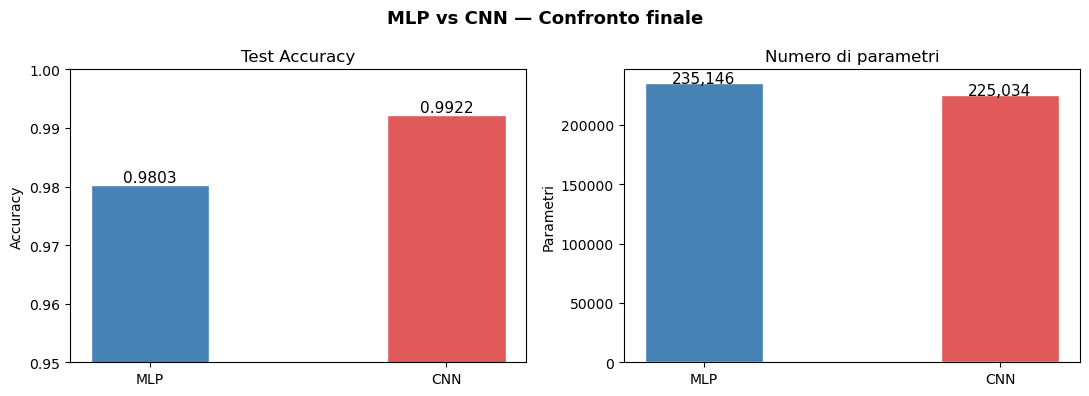

In [49]:
# Riepilogo
modelli_info = {
    "MLP": {"acc": acc_mlp_test, "params": n_params_mlp},
    "CNN": {"acc": acc_cnn_test, "params": n_params_cnn},
}

print("=" * 50)
print(f"{'Modello':<10} {'Accuracy':>10} {'Parametri':>12}")
print("-" * 50)
for nome, info in modelli_info.items():
    print(f"{nome:<10} {info['acc']:>10.4f} {info['params']:>12,}")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Accuracy
nomi  = list(modelli_info.keys())
accs  = [modelli_info[n]["acc"] for n in nomi]
colori = ['steelblue', '#E05A5A']
axes[0].bar(nomi, accs, color=colori, edgecolor='white', width=0.4)
axes[0].set_ylim(0.95, 1.0)
axes[0].set_title("Test Accuracy")
axes[0].set_ylabel("Accuracy")
for i, (n, a) in enumerate(zip(nomi, accs)):
    axes[0].text(i, a + 0.0005, f"{a:.4f}", ha='center', fontsize=11)

# Parametri
params = [modelli_info[n]["params"] for n in nomi]
axes[1].bar(nomi, params, color=colori, edgecolor='white', width=0.4)
axes[1].set_title("Numero di parametri")
axes[1].set_ylabel("Parametri")
for i, (n, p) in enumerate(zip(nomi, params)):
    axes[1].text(i, p + 500, f"{p:,}", ha='center', fontsize=11)

plt.suptitle("MLP vs CNN — Confronto finale", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Conclusioni

### Cosa abbiamo imparato

| Concetto | Spiegazione |
|---|---|
| **DataLoader + mini-batch** | Permette di addestrare su dataset che non entrano in memoria |
| **Transforms** | Preprocessing standardizzato e riproducibile |
| **Dropout** | Regolarizzazione che riduce l'overfitting |
| **Conv2d** | Filtri che scorrono sull'immagine e imparano pattern locali |
| **MaxPooling** | Riduce le dimensioni spaziali, aumenta il campo recettivo |
| **Feature maps** | Rappresentazione interna di cosa "vede" la rete |

### Perché la CNN è più efficiente dell'MLP?

- Ha **meno parametri** pur ottenendo accuracy più alta
- Sfrutta la **struttura spaziale** dell'immagine (i pixel vicini sono correlati)
- I filtri sono **condivisi** — lo stesso filtro rileva un bordo ovunque nell'immagine
- È **più robusta** a piccole traslazioni grazie al pooling

### Prossimi passi

- Aumentare le epoch per migliorare ulteriormente l'accuracy
- Aggiungere **BatchNormalization** per una convergenza più stabile
- Provare architetture più profonde (più strati conv)
- Applicare **data augmentation** (rotazioni, zoom) per aumentare la robustezza
- Esplorare architetture classiche: **LeNet-5**, **VGG**, **ResNet**
